# <center><span style='color:red'><b>Climatology Stats</b></span></center>

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
# Open with xarray
data = xr.open_zarr('/gws/nopw/j04/co2clim/datasets/GLORYS/GLOBAL_MULTIYEAR_PHY_001_030/Subset_NorthAtlantic_regrid1x1/cmems_mod_glo_phy_my_0.083deg_P1D-m_mlotst_100.00W-20.00E_0.00N-80.00N_1993-01-01-2021-06-30.zarr').load()

# Print a summary of dataset
print(data)

<xarray.Dataset> Size: 408MB
Dimensions:    (latitude: 81, longitude: 121, time: 10408)
Coordinates:
  * latitude   (latitude) float64 648B 0.0 1.0 2.0 3.0 ... 77.0 78.0 79.0 80.0
  * longitude  (longitude) float64 968B -100.0 -99.0 -98.0 ... 18.0 19.0 20.0
  * time       (time) datetime64[ns] 83kB 1993-01-01 1993-01-02 ... 2021-06-30
Data variables:
    mlotst     (time, latitude, longitude) float32 408MB 10.53 10.53 ... nan nan


## Compute seasonal means
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [3]:
# Ensure time is sorted
data = data.sortby('time')

# Add season and year
data = data.assign_coords(season=data['time'].dt.season, year=data['time'].dt.year)

# Remove incomplete DJF seasons
# (require Dec, Jan, Feb to exist)
djf_counts = (data.where(data.season == 'DJF', drop=True).groupby('year').count('time'))

valid_djf_years = djf_counts.where(djf_counts >= 3, drop=True).year

# Keep only years with full DJF
data_clipped = data.where(data.year.isin(valid_djf_years), drop=True)

# Now compute seasonal means
seasonal_means = data_clipped.groupby('season').mean('time', skipna=True)

## Rectangle definition
<hr style='border: solid 2px red;'>

In [30]:
rect_coords = (-35, -25, 26, 29)  # (minlon, maxlon, minlat, maxlat)
rminlon, rmaxlon, rminlat, rmaxlat = rect_coords

## Mapping
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [5]:
def make_boundary_path(minlon, maxlon, minlat, maxlat, n=50):
    """Return a matplotlib Path representing the map boundary (curved edges)."""
    boundary_path = []
    # North (W→E)
    edge = [np.linspace(minlon, maxlon, n), np.full(n, maxlat)]
    boundary_path += [[i, j] for i, j in zip(*edge)]
    # East (N→S)
    edge = [np.full(n, maxlon), np.linspace(maxlat, minlat, n)]
    boundary_path += [[i, j] for i, j in zip(*edge)]
    # South (E→W)
    edge = [np.linspace(maxlon, minlon, n), np.full(n, minlat)]
    boundary_path += [[i, j] for i, j in zip(*edge)]
    # West (S→N)
    edge = [np.full(n, minlon), np.linspace(minlat, maxlat, n)]
    boundary_path += [[i, j] for i, j in zip(*edge)]

    return mpath.Path(boundary_path)

In [6]:
def map_mld_panel(
    seasonal_means, lons, lats,
    varname='mlotst',
    rect_coords=None):
   
    """
    Plot a 2x2 panel of seasonal mean MLD maps with same formatting
    and optionally add a manual rectangle in each panel.
    """

    seasons = ['DJF', 'MAM', 'JJA', 'SON']

    # Global min/max for shared color scale
    all_data = np.concatenate([
        seasonal_means.sel(season=s)[varname].values.flatten()
        for s in seasons])
    
    vmin, vmax = np.nanmin(all_data), np.nanmax(all_data)

    # Map extent & projection
    minlon, maxlon = float(np.min(lons)), float(np.max(lons))
    minlat, maxlat = float(np.min(lats)), float(np.max(lats))
    midlon, midlat = (minlon + maxlon)/2, (minlat + maxlat)/2
    extent = [minlon, maxlon, minlat, maxlat]

    boundary = make_boundary_path(minlon, maxlon, minlat, maxlat)

    proj = ccrs.LambertAzimuthalEqualArea(
        central_longitude=midlon,
        central_latitude=midlat)

    # Figure and axes
    fig, axes = plt.subplots(
        2, 2, figsize=(12, 10),
        subplot_kw={'projection': proj})
    axes = axes.flatten()

    clevs = np.arange(0, 210, 10)
    cticks = np.arange(0, 220, 20)

    for ax, season in zip(axes, seasons):

        data = seasonal_means.sel(season=season)[varname]

        cf = ax.contourf(
            lons, lats, data.values,
            levels=clevs, cmap='viridis', extend='both',
            transform=ccrs.PlateCarree())


        # Curved boundary
        ax.set_boundary(boundary, transform=ccrs.PlateCarree())
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        # Land, borders, etc.
        ax.coastlines(color='k', linewidth=0.4)
        ax.add_feature(cfeature.BORDERS, linewidth=0.2)
        ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=0)

        # Title
        ax.set_title(season, weight='bold', fontsize=12)

        # 🔴 DRAW RECTANGLE (same location in every panel)
        # ------------------------------------------------
        if rect_coords is not None:
            rminlon, rmaxlon, rminlat, rmaxlat = rect_coords

            rect_lons = [rminlon, rmaxlon, rmaxlon, rminlon, rminlon]
            rect_lats = [rminlat, rminlat, rmaxlat, rmaxlat, rminlat]

            ax.plot(
                rect_lons, rect_lats,
                color='red', linewidth=1.4,
                transform=ccrs.PlateCarree(),
                zorder=10)

    # Colorbar
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
    cb = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal', ticks=cticks)
    cb.set_label('Mean MLD (m)', fontsize=10)
    cb.ax.tick_params(labelsize=9)

    fig.subplots_adjust(
        left=0.05, right=0.95,
        bottom=0.15, top=0.92,
        wspace=0.25, hspace=0.25)

    fig.suptitle("Seasonal Mean Mixed Layer Depth (MLD)",
                 fontsize=14, weight='bold')

    plt.show()

    return fig

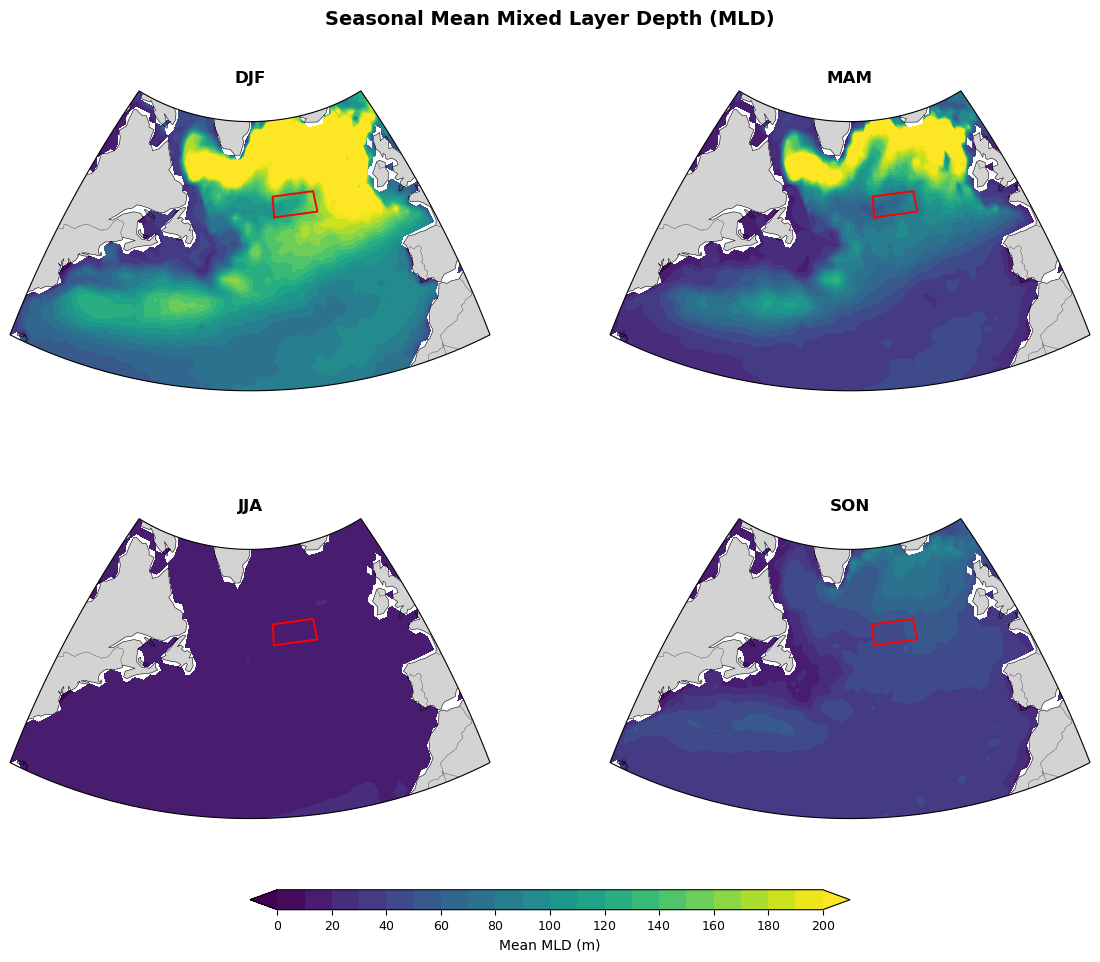

In [12]:
# Crop your data first
minlat, maxlat = 26, 65
minlon, maxlon = -80, -1
data_crop = seasonal_means.sel(latitude=slice(minlat, maxlat),
                               longitude=slice(minlon, maxlon))

# As numpy arrays
lons_crop = data_crop.longitude.values
lats_crop = data_crop.latitude.values

# Then pass the cropped data and coordinates to the plotting function
fig_cropped = map_mld_panel(data_crop, lons=lons_crop, lats=lats_crop, varname='mlotst', rect_coords=rect_coords)


# SAVE FIGURE
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

outfile = FIG_DIR / f"mappanel_{rect_coords}.png"
fig_cropped.savefig(outfile, dpi=300, bbox_inches='tight')

## Statistical analysis (time series)
<hr style='border: solid 2px blue;'>

In [35]:
# =====================================================================================
# DATA PREPARATION
# =====================================================================================
rect_mean = (
    data['mlotst']
    .sel(latitude=slice(rminlat, rmaxlat),
         longitude=slice(rminlon, rmaxlon))
    .mean(dim=['latitude', 'longitude'], skipna=True)
)

# Remove Feb 29 globally
rect_mean = rect_mean.where(rect_mean['time.dayofyear'] != 366, drop=True)


# Global y-axis limits
MLD_YLIM = (180, 0)
MEAN_MEDIAN_YLIM = (-15, 15)   # metres, adjust as needed
SKEWNESS_YLIM = (-4, 4)      # dimensionless

# =====================================================================================
# SHIFT DAY-OF-YEAR FOR DECEMBER START
# =====================================================================================
def shift_doy_to_dec(doy):
    """Shift day-of-year so Dec 1 = 1."""
    return doy - 334 if doy >= 335 else doy + 31

# =====================================================================================
# CONVERT TO DATAFRAME
# =====================================================================================
df = rect_mean.to_dataframe(name='MLD').reset_index()
df['year'] = df['time'].dt.year
df['doy'] = df['time'].dt.dayofyear
df['doy_dec'] = df['doy'].apply(shift_doy_to_dec)

# Grouped statistics by shifted DOY
grouped_dec = df.groupby('doy_dec')
days_dec = sorted(grouped_dec.groups.keys())

climatology = grouped_dec['MLD'].mean()
median_doy = grouped_dec['MLD'].median()
daily_min = grouped_dec['MLD'].min()
daily_max = grouped_dec['MLD'].max()
daily_std = grouped_dec['MLD'].std()
cv = daily_std / climatology

# Seasonal boundaries (still standard DOY)
season_boundaries = [1, 91, 182, 274, 366]

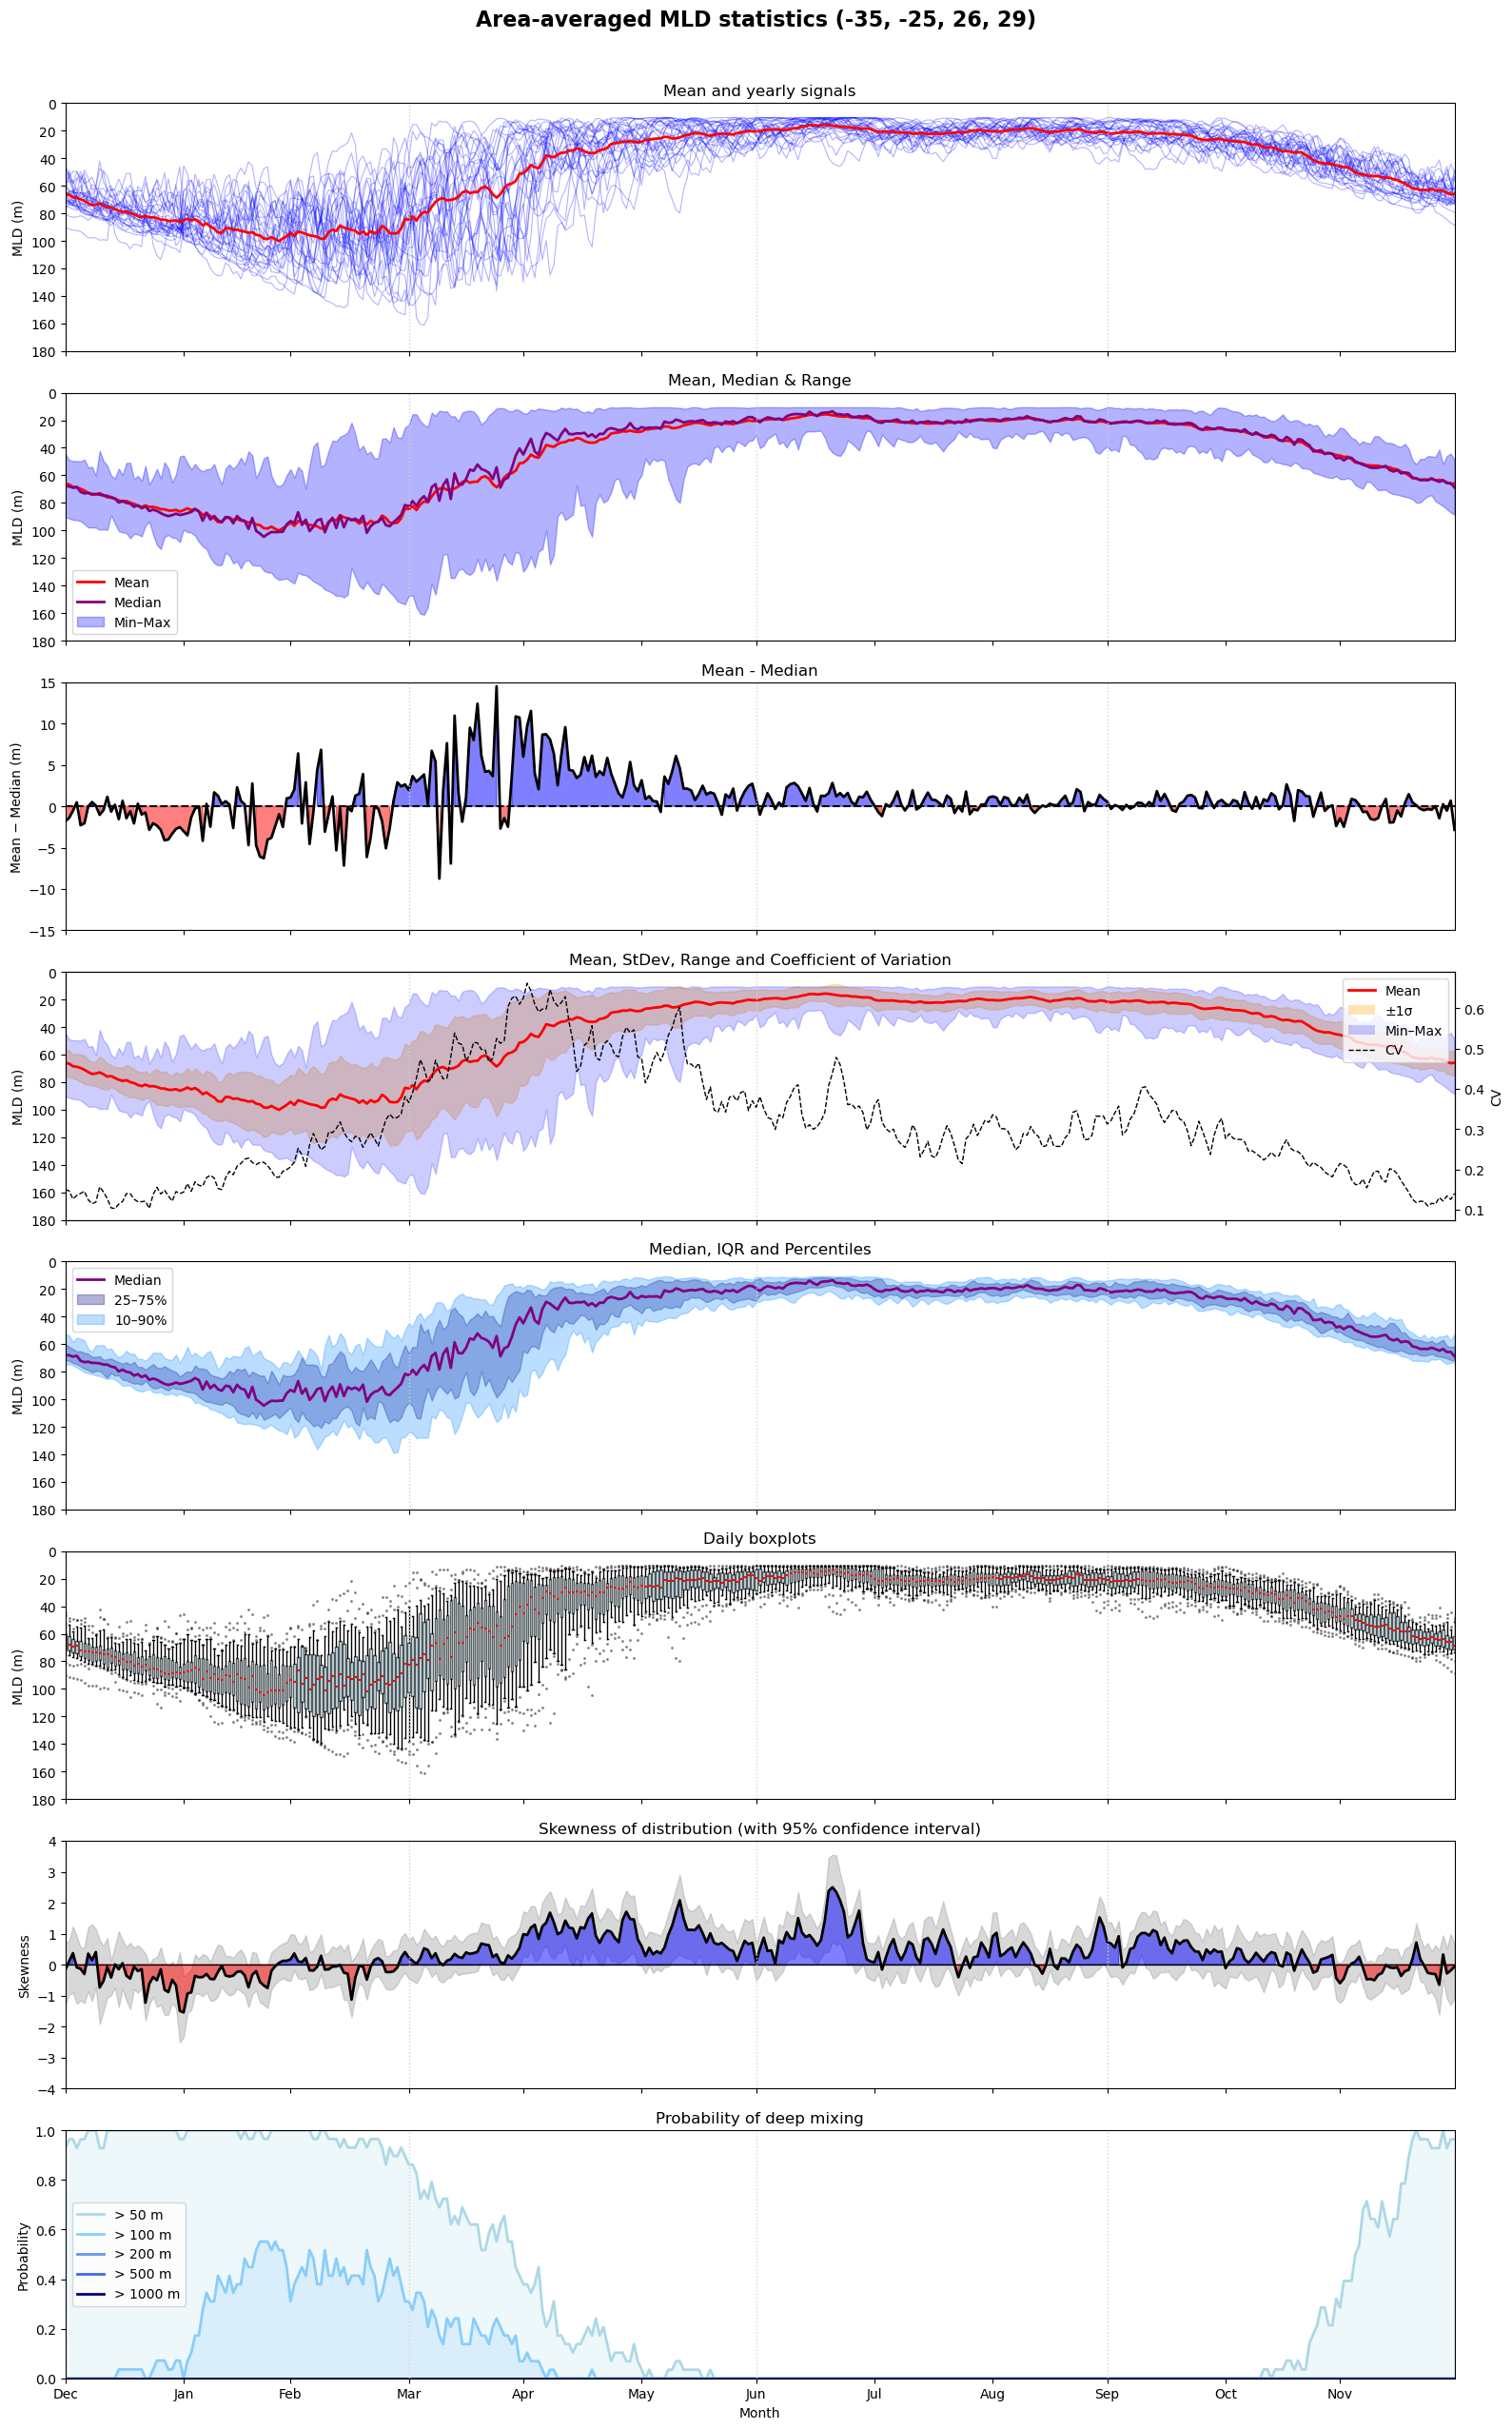

In [36]:
# =====================================================================================
# COMPOSITE FIGURE
# =====================================================================================
fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(16, 26), sharex=True)

# -----------------------------------------------------
# HELPER FUNCTIONS
# -----------------------------------------------------
def add_season_lines(ax):
    for start in season_boundaries[:-1]:
        ax.axvline(start, color='lightgrey', lw=1, linestyle=':')
    ax.set_xlim(1, 365)

def set_month_ticks_dec_start(ax):
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_labels = ['Dec','Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov']
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels)

def set_fixed_mld_ylim(ax):
    ax.set_ylim(MLD_YLIM)
    ax.invert_yaxis()


# =====================================================================================
# 1) SPAGHETTI + CLIMATOLOGY
# =====================================================================================
ax = axes[0]
for year, group in df.groupby('year'):
    g = group.sort_values('doy_dec')
    ax.plot(g['doy_dec'], g['MLD'], color='blue', alpha=0.3, lw=0.8)
ax.plot(climatology.index, climatology.values, color='red', lw=2)
ax.set_ylabel('MLD (m)')
ax.set_title('Mean and yearly signals')
set_fixed_mld_ylim(ax)
ax.invert_yaxis()
add_season_lines(ax)

# =====================================================================================
# 2) MEAN & MEDIAN + MIN–MAX
# =====================================================================================
ax = axes[1]
ax.plot(days_dec, climatology, color='red', lw=2, label='Mean')
ax.plot(days_dec, median_doy, color='purple', lw=2, label='Median')
ax.fill_between(days_dec, daily_min, daily_max, color='blue', alpha=0.3, label='Min–Max')
ax.set_ylabel('MLD (m)')
ax.set_title('Mean, Median & Range')
set_fixed_mld_ylim(ax)
ax.invert_yaxis()
ax.legend()
add_season_lines(ax)

# =====================================================================================
# 3) MEAN − MEDIAN
# =====================================================================================
mean_minus_median = climatology - median_doy
ax = axes[2]
ax.fill_between(days_dec, 0, mean_minus_median, where=mean_minus_median > 0,
                color='blue', alpha=0.5)
ax.fill_between(days_dec, 0, mean_minus_median, where=mean_minus_median < 0,
                color='red', alpha=0.5)
ax.plot(days_dec, mean_minus_median, color='black', lw=2)
ax.axhline(0, color='black', linestyle='--')
ax.set_ylabel('Mean − Median (m)')
ax.set_title('Mean - Median')
ax.set_ylim(MEAN_MEDIAN_YLIM)
add_season_lines(ax)

# =====================================================================================
# 4) MEAN DISTRIBUTION (+ CV)
# =====================================================================================
from matplotlib.patches import Patch
ax = axes[3]
line_mean, = ax.plot(days_dec, climatology, color='red', lw=2, label='Mean')
shade_std = ax.fill_between(days_dec, climatology - daily_std, climatology + daily_std,
                            color='orange', alpha=0.3)
shade_minmax = ax.fill_between(days_dec, daily_min, daily_max, color='blue', alpha=0.2)
ax.set_ylabel('MLD (m)')
ax.set_title('Mean, StDev, Range and Coefficient of Variation')
set_fixed_mld_ylim(ax)
ax.invert_yaxis()
add_season_lines(ax)

ax2 = ax.twinx()
line_cv, = ax2.plot(days_dec, cv, color='black', lw=1, linestyle='--', label='CV')
ax2.set_ylabel('CV')


# Legend including shaded areas
legend_elements = [line_mean, Patch(facecolor='orange', alpha=0.3, label='±1σ'), Patch(facecolor='blue', alpha=0.2, label='Min–Max'), line_cv]
ax.legend(handles=legend_elements, loc='upper right')

# =====================================================================================
# 7) MEDIAN DISTRIBUTION
# =====================================================================================
median = median_doy
q25 = grouped_dec['MLD'].quantile(0.25)
q75 = grouped_dec['MLD'].quantile(0.75)
p10 = grouped_dec['MLD'].quantile(0.10)
p90 = grouped_dec['MLD'].quantile(0.90)

ax = axes[4]
ax.plot(days_dec, median, color='purple', lw=2, label='Median')
ax.fill_between(days_dec, q25, q75, color='navy', alpha=0.3, label='25–75%')
ax.fill_between(days_dec, p10, p90, color='dodgerblue', alpha=0.3, label='10–90%')
ax.set_ylabel('MLD (m)')
ax.set_title('Median, IQR and Percentiles')
set_fixed_mld_ylim(ax)
ax.invert_yaxis()
ax.legend()
add_season_lines(ax)

# =====================================================================================
# 5) BOXPLOTS BY DAY OF YEAR
# =====================================================================================
ax = axes[5]
boxplot_data = [group['MLD'].values for _, group in grouped_dec]
ax.boxplot(
    boxplot_data,
    positions=days_dec,
    widths=0.6,
    whis=[5, 95],
    showfliers=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=1.5),
    flierprops=dict(marker='.', markersize=2, alpha=0.5))
ax.set_ylabel('MLD (m)')
set_fixed_mld_ylim(ax)
ax.invert_yaxis()
ax.set_title('Daily boxplots')
add_season_lines(ax)

# =====================================================================================
# 6) SKEWNESS (WITH 95% CI)
# =====================================================================================
from scipy.stats import skew

skew_vals = np.array([skew(group['MLD'].values, bias=False) for _, group in grouped_dec])
n_boot = 1000
ci_low, ci_high = [], []
rng = np.random.default_rng(seed=42)
for _, group in grouped_dec:
    vals = group['MLD'].values
    boot = [skew(rng.choice(vals, size=len(vals), replace=True), bias=False)
            for _ in range(n_boot)]
    ci_low.append(np.percentile(boot, 2.5))
    ci_high.append(np.percentile(boot, 97.5))

ax = axes[6]
ax.fill_between(days_dec, ci_low, ci_high, color='grey', alpha=0.3, label='95% CI')
ax.fill_between(days_dec, 0, skew_vals, where=skew_vals > 0, color='blue', alpha=0.5)
ax.fill_between(days_dec, 0, skew_vals, where=skew_vals < 0, color='red', alpha=0.5)
ax.plot(days_dec, skew_vals, color='black', lw=2)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Skewness')
ax.set_title('Skewness of distribution (with 95% confidence interval)')
ax.set_ylim(SKEWNESS_YLIM)
add_season_lines(ax)


# =====================================================================================
# 8) PROBABILITY OF DEEP MIXING
# =====================================================================================
thresholds = [50, 100, 200, 500, 1000]
prob = {t: [np.mean(group['MLD'].values > t) for _, group in grouped_dec] for t in thresholds}

ax = axes[7]
ax.plot(days_dec, prob[50], color='lightblue', lw=2, label='> 50 m')
ax.plot(days_dec, prob[100], color='lightskyblue', lw=2, label='> 100 m')
ax.plot(days_dec, prob[200], color='cornflowerblue', lw=2, label='> 200 m')
ax.plot(days_dec, prob[500], color='royalblue', lw=2, label='> 500 m')
ax.plot(days_dec, prob[1000], color='navy', lw=2, label='> 1000 m')
ax.fill_between(days_dec, 0, prob[50], color='lightblue', alpha=0.2)
ax.fill_between(days_dec, 0, prob[100], color='lightskyblue', alpha=0.2)
ax.fill_between(days_dec, 0, prob[200], color='cornflowerblue', alpha=0.2)
ax.fill_between(days_dec, 0, prob[500], color='royalblue', alpha=0.2)
ax.fill_between(days_dec, 0, prob[1000], color='navy', alpha=0.2)
ax.set_ylabel('Probability')
ax.set_ylim(0, 1)
ax.set_title('Probability of deep mixing')
ax.legend()
add_season_lines(ax)

# =====================================================================================
# FINAL TOUCHES + SAVE
# =====================================================================================
axes[-1].set_xlabel('Month')
set_month_ticks_dec_start(axes[-1])

fig.suptitle(f'Area-averaged MLD statistics {rect_coords}',
             fontsize=16, weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])

outfile = FIG_DIR / f"adj_stats_timeseries_{rect_coords}.png"


In [37]:
fig.savefig(outfile, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved figure to: {outfile}")

Saved figure to: figures/adj_stats_timeseries_(-35, -25, 26, 29).png
